In [1]:
!rm -rf *

### SCC02713 - Introdução à Bioinformática
## Trabalho Prático: Classificação de Elementos Transponíveis

#### Docente: Ricardo Cerri

#### Alunos:

* Alec C. Aoki (15436800);
* Matheus V. Fernandes (14615993);
* Pedro A. F. Paffaro (15483380).

---

## Dependências

---

Baixamos e importamos as biblioteccas usadas, além da ferramenta MathFeature e os arquivos gffs e fasta necessários.

In [2]:
%pip install biopython
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install -q gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 23.1 MB/s eta 0:00:00


Importando as que serão bibliotecas usadas.

In [3]:
import csv
import os
from Bio import SeqIO, Entrez
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm import tqdm
from types import SimpleNamespace
import yaml
import re
import subprocess
import shutil
from pathlib import Path
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    roc_auc_score
)
from sklearn.metrics import confusion_matrix
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

Baixando o MathFeature (diretamente do github).

In [4]:
# Baixando a ferramenta MathFeature
!git clone https://github.com/Bonidia/MathFeature.git

Cloning into 'MathFeature'...
remote: Enumerating objects: 860, done.
remote: Counting objects: 100% (279/279), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 860 (delta 140), reused 244 (delta 117), pack-reused 581 (from 1)
Receiving objects: 100% (860/860), 111.94 MiB | 22.15 MiB/s, done.
Resolving deltas: 100% (491/491), done.
Updating files: 100% (153/153), done.


Foram baixados seis arquivos no formato .gff3, correspondentes às classes Helitron, LINE, LTR, MITE, SINE e TIR.

In [5]:
# Baixando os arquivos gffs
!mkdir -p gffs
classes = ['LTR', 'LINE', 'SINE', 'TIR', 'MITE', 'Helitron']
for c in classes:
    !wget http://apte.cp.utfpr.edu.br/te-annotation/zea_mays/TEAnnotationFinal_{c}.gff3 -P gffs/

--2025-11-09 20:39:05--  http://apte.cp.utfpr.edu.br/te-annotation/zea_mays/TEAnnotationFinal_LTR.gff3
Resolving apte.cp.utfpr.edu.br (apte.cp.utfpr.edu.br)... 200.134.22.76
Connecting to apte.cp.utfpr.edu.br (apte.cp.utfpr.edu.br)|200.134.22.76|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 39972274 (38M)
Saving to: ‘gffs/TEAnnotationFinal_LTR.gff3’

TEAnnotationFinal_L 100%[===================>]  38.12M  12.7MB/s    in 3.0s    

2025-11-09 20:39:09 (12.7 MB/s) - ‘gffs/TEAnnotationFinal_LTR.gff3’ saved [39972274/39972274]

--2025-11-09 20:39:09--  http://apte.cp.utfpr.edu.br/te-annotation/zea_mays/TEAnnotationFinal_LINE.gff3
Resolving apte.cp.utfpr.edu.br (apte.cp.utfpr.edu.br)... 200.134.22.76
Connecting to apte.cp.utfpr.edu.br (apte.cp.utfpr.edu.br)|200.134.22.76|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2262785 (2.2M)
Saving to: ‘gffs/TEAnnotationFinal_LINE.gff3’

TEAnnotationFinal_L 100%[===================>]   2.16M  2.11MB

Baixando os arquivos .fasta dos genomas de referência dos cromossomos de Z. mays, pelo NCBI via BioPython.

In [6]:
# Baixando os arquivos fasta
Entrez.email = "alec.aoki@usp.br"

# Criar pasta
!mkdir -p fastas
fasta_folder = "./fastas/"

# Baixar as sequências
num_acesso = [f"LR6188{i}" for i in range(74, 84)]
max_tentativas = 5  # Número máximo de tentativas por sequência
tempo_espera = 3  # Segundos de espera entre tentativas

pendentes = list(enumerate(num_acesso, start=1))  # Lista de (index, accession) pendentes
sucesso = set()  # Conjunto de índices baixados com sucesso

while pendentes:
    proxima_rodada = []

    for i, accession in pendentes:
        if i in sucesso:
            continue

        try:
            print(f"Processando cromossomo {accession} (sequência {i})")
            handle = Entrez.efetch(db="nucleotide",
                                   id=accession,
                                   rettype="fasta",
                                   retmode="text")
            # Salvar no arquivo
            with open(f"fastas/sequence{i}.fasta", "w") as f:
                f.write(handle.read())
                print(f"sequence{i}.fasta salva com sucesso")
            handle.close()
            sucesso.add(i)

        except Exception as e:
            print(f"Erro ao baixar {accession}: {e}")
            proxima_rodada.append((i, accession))

        # Pequena pausa entre requisições para não sobrecarregar o servidor
        time.sleep(1)

    # Atualizar lista de pendentes
    if proxima_rodada:
        print(f"\n{len(proxima_rodada)} sequência(s) falharam. Tentando novamente em {tempo_espera} segundos...\n")
        time.sleep(tempo_espera)
        pendentes = proxima_rodada
    else:
        pendentes = []

Processando cromossomo LR618874 (sequência 1)
sequence1.fasta salva com sucesso
Processando cromossomo LR618875 (sequência 2)
sequence2.fasta salva com sucesso
Processando cromossomo LR618876 (sequência 3)
sequence3.fasta salva com sucesso
Processando cromossomo LR618877 (sequência 4)
sequence4.fasta salva com sucesso
Processando cromossomo LR618878 (sequência 5)
sequence5.fasta salva com sucesso
Processando cromossomo LR618879 (sequência 6)
sequence6.fasta salva com sucesso
Processando cromossomo LR618880 (sequência 7)
sequence7.fasta salva com sucesso
Processando cromossomo LR618881 (sequência 8)
sequence8.fasta salva com sucesso
Processando cromossomo LR618882 (sequência 9)
sequence9.fasta salva com sucesso
Processando cromossomo LR618883 (sequência 10)
sequence10.fasta salva com sucesso


---

## Geração do Conjunto de Dados

---

É realizado o processamento das anotações contidas nos arquivos GFF3 com o objetivo de recuperar apenas as entradas localizadas na fita positiva. De cada linha foram extraídos: o cromossomo (Chr) e as posições de início e fim
(Start e End) de cada TE.

Os arquivos FASTA e GFF3 foram integrados usando o BioPython, responsável por mapear as posições genômicas e extrair as respectivas sequências de TEs.

O processo de montagem foi automatizado e seu pipeline realiza as seguintes eta-
pas principais:
- Cada arquivo .gff3 é lido e seus TEs são agrupados em um dicionário;
- As chaves do dicionário são ordenadas numericament e alfabeticamente para manter a coerência com os nomes dos arquivos FASTA;
- Para cada cromossomo, o script acessa o arquivo FASTA correspondente extraindo
as subsequências delimitadas pelos valores de Start e End, e as associa à classe TE de origem;
- Ao final, são gerados dois arquivos: um arquivo CSV contendo as colunas Cro-
mossomo, Sequência TE e Classe e um arquivo com as mesmas sequências em
formato FASTA padronizado que será utilizado para extração das características.

In [7]:
def criar_mapa_TE_agrupado():
    """
    Lê todos os arquivos GFF e agrupa as informações de TE por cromossomo
    em um dicionário. Estrutura do dicionário de saída:
    {
        '1': [(comeco, fim, 'CLASSE'), (comeco, fim, 'CLASSE'), ...],
        '2': [(comeco, fim, 'CLASSE'), ...],
        ...
    }
    """
    mapa_TE = {}

    # Itera sobre o dicionário de classes e arquivos GFF
    for classe_TE, arq_gff in gffs.items():
        with open(arq_gff) as infile:
            reader = csv.reader(infile, delimiter="\t")
            for linha in reader:
                # Ignora linhas de comentário ou vazias
                if linha and not linha[0].startswith("#"):
                    chrom = linha[0]
                    comeco = int(linha[3])
                    fim = int(linha[4])
                    fita = linha[6]

                    # Filtra apenas a fita positiva
                    if fita == '+':
                        # Se o cromossomo ainda não está no nosso mapa, cria uma lista vazia para ele
                        if chrom not in mapa_TE:
                            mapa_TE[chrom] = []

                        # Adiciona as informações do TE (start, end, class) à lista do cromossomo
                        mapa_TE[chrom].append((comeco, fim, classe_TE))

    return mapa_TE

def sort_TEs_agrupados(TEs_agrupados):
    """
    Ordena os TEs por cromossomo
    """
    chaves_chroms = list(TEs_agrupados.keys())

    def ordenar_chaves(chave):
        """
        Cria uma chave de ordenação para strings.
        - Se a string for um número, ela terá prioridade e será tratada como um int.
        - Se for texto, terá prioridade menor e será tratada como string.
        """
        if chave.isdigit():
            # Retorna uma tupla: (prioridade, valor numérico)
            return (0, int(chave))
        else:
            # Retorna uma tupla: (prioridade, valor de texto)
            return (1, chave)

    chaves_chroms_ord = sorted(chaves_chroms, key=ordenar_chaves)
    TEs_agrupados_ord = {i: TEs_agrupados[i] for i in chaves_chroms_ord}

    return TEs_agrupados_ord

def extrair_sequences_para_csv(mapa_TE, fasta_folder, output_csv):
    """
    Extrai as sequências de TEs processando um cromossomo de cada vez
    """
    print(f"Extraindo sequências para o arquivo {output_csv}")

    # Abre o arquivo de saída e escreve o cabeçalho
    with open(output_csv, "w", newline="") as outfile:
        writer = csv.writer(outfile)
        writer.writerow(["Cromossomo", "Sequencia_TE", "Classe"])

        # Itera sobre cada cromossomo que encontramos nos arquivos GFF
        for chrom, lista_TE in mapa_TE.items():
            fasta_file_path = os.path.join(fasta_folder, f"sequence{chrom}.fasta")

            # Verifica se o arquivo .fasta para este cromossomo existe
            if not os.path.exists(fasta_file_path):
                #print(f"Arquivo FASTA não encontrado para o cromossomo {chrom}. Pulando")
                continue

            # 1. Carrega o genoma do cromossomo atual
            registo_chrom = SeqIO.read(fasta_file_path, "fasta")
            sequencia_chrom = registo_chrom.seq

            # 2. Itera sobre a lista de TEs para este cromossomo
            for info_TE in lista_TE:
                comeco, fim, classe_TE = info_TE

                # 3. Extrai a sequência
                sequencia_TE = sequencia_chrom[comeco-1:fim]

                # 4. Escreve o resultado no arquivo CSV
                writer.writerow([chrom, str(sequencia_TE), classe_TE])

def extrair_sequencias_para_fasta(mapa_TE, fasta_folder, output_fasta):
    """
    Extrai as sequências de TEs e as salva em um único arquivo FASTA,
    verificando se as coordenadas estão dentro dos limites da sequência do cromossomo
    """
    written_counter = 0

    with open(output_fasta, "w") as outfile:
        for chrom, lista_TE in mapa_TE.items():
            fasta_file_path = os.path.join(fasta_folder, f"sequence{chrom}.fasta")

            if not os.path.exists(fasta_file_path):
                #print(f"Arquivo FASTA não encontrado para o cromossomo {chrom}. Pulando")
                continue

            registro_chrom = SeqIO.read(fasta_file_path, "fasta")
            sequencia_chrom = registro_chrom.seq
            tam_chrom = len(sequencia_chrom)

            for info_TE in lista_TE:
                comeco, fim, classe_TE = info_TE

                if comeco > tam_chrom:
                    #print(f"Coordenadas inválidas para TE no cromossomo {chrom}.")
                    continue

                sequencia_TE = sequencia_chrom[comeco-1:fim]

                if sequencia_TE:
                    written_counter += 1
                    header = f">TE_{written_counter}_Chr-{chrom}_Class-{classe_TE}_Coords-{comeco}-{fim}"

                    outfile.write(header + "\n")
                    outfile.write(str(sequencia_TE) + "\n")

def mapear_TEs():
    """
    Cria mapeamento de TEs
    """
    TEs_agrupados = criar_mapa_TE_agrupado()
    TEs_agrupados_ord = sort_TEs_agrupados(TEs_agrupados)

    print(f"\nMapeamento concluído. Total de cromossomos: {len(TEs_agrupados_ord)}")
    return TEs_agrupados_ord

def extrair_sequencias(TEs_agrupados_ord=None):
    """
    Extrai sequências
    """
    if TEs_agrupados_ord is None:
        print("Mapeamento de TEs não encontrado. Criando")
        TEs_agrupados_ord = mapear_TEs()

    output_file_fasta = "sequencias_TEs.fasta"
    output_file_csv = "sequencias_TEs.csv"

    extrair_sequences_para_csv(TEs_agrupados_ord, fasta_folder, output_file_csv)
    extrair_sequencias_para_fasta(TEs_agrupados_ord, fasta_folder, output_file_fasta)

    print(f"\nArquivos gerados:")
    print(f"{output_file_csv}")
    print(f"{output_file_fasta}")

def run_pipeline_gff():
    # Etapa 1
    sorted_grouped_tes = mapear_TEs()

    # Etapa 2
    extrair_sequencias(sorted_grouped_tes)

---

## Filtragem do Conjunto de Dados

---

O conjunto de dados bruto resultante das operações anteriores resultou em cerca de 338 mil sequências. Visando facilitar a extração das características e remover ruído. Ao todo foram removidas 202826 sequências (59.9% do conjunto de dados original).

In [8]:
TAMANHOS_CLASSE = {
  "LTR": (1000, 15000),
  "LINE": (1500, 8000),
  "SINE": (50, 600),
  "TIR": (300, 10000),
  "MITE": (50, 800),
  "Helitron": (500, 20000)
}

def carregar_csv(csv_path):
    """
    Carrega os dados do CSV e calcula métricas de qualidade
    """
    cleaner = SimpleNamespace()  # Cria objeto
    cleaner.df = pd.read_csv(csv_path)

    seqs = cleaner.df['Sequencia_TE'].astype(str)

    # Métricas de qualidade pras sequências
    cleaner.df['tamanho'] = [len(seq) for seq in tqdm(seqs, desc="Tamanhos", ncols=80)]

    # Proporção de bases ambíguas (N)
    cleaner.df['prop_N'] = [seq.count('N') / len(seq) if len(seq) > 0 else 0
                            for seq in tqdm(seqs, desc="Proporção de N's", ncols=80)]

    # Conteúdo GC (% de guaninas e citosinas)
    cleaner.df['conteudo_GC'] = [(seq.count('G') + seq.count('C')) / len(seq) if len(seq) > 0 else 0
                                for seq in tqdm(seqs, desc="GC%", ncols=80)]

    return cleaner

def mostrar_estatisticas(sequencias):
  """
  Exibe estatísticas dos dados carregados
  """
  # Total de sequências
  print(f"\nTotal de sequências: {len(sequencias.df)}")

  # Distribuição por classe de TE
  print("\nDistribuição por classe:")
  quant_classe = sequencias.df['Classe'].value_counts()
  for classe in quant_classe.index:
      count = quant_classe[classe]
      prop = (count / len(sequencias.df)) * 100
      print(f"  {classe:15s}: {count:7d} ({prop:5.2f}%)")

  # Estatísticas de tamanho
  print(f"\nTamanhos:")
  print(f"  Mínimo:  {sequencias.df['tamanho'].min():8d} bp")
  print(f"  Máximo:  {sequencias.df['tamanho'].max():8d} bp")
  print(f"  Média:   {sequencias.df['tamanho'].mean():8.0f} bp")
  print(f"  Mediana: {sequencias.df['tamanho'].median():8.0f} bp")

  # Métricas de qualidade
  print(f"\nQualidade (bases ambíguas N):")
  soma_N = (sequencias.df['prop_N'] > 0.1).sum()
  print(f"  Sequências com >10% Ns: {soma_N}")
  soma_N = (sequencias.df['prop_N'] > 0.05).sum()
  print(f"  Sequências com >5% Ns: {soma_N}")
  soma_N = (sequencias.df['prop_N'] > 0.01).sum()
  print(f"  Sequências com >1% Ns: {soma_N}")
  soma_N = (sequencias.df['prop_N'] > 0.001).sum()
  print(f"  Sequências com >0.1% Ns: {soma_N}")
  soma_N = (sequencias.df['prop_N'] > 0.0001).sum()
  print(f"  Sequências com >0.01% Ns: {soma_N}")

  # Caracteres inválidos (!= ATCGN)
  invalidos = sequencias.df['Sequencia_TE'].astype(str).apply(
      lambda x: not set(x).issubset(set('ATCGN'))
  ).sum()
  print(f"  Sequências com caracteres inválidos: {invalidos}")

  # Duplicatas
  duplicatas = sequencias.df.duplicated(subset=['Sequencia_TE']).sum()
  print(f"  Sequências duplicadas: {duplicatas}")

  # Conteúdo GC
  print(f"\nConteúdo GC:")
  print(f"  Média: {sequencias.df['conteudo_GC'].mean()*100:.1f}%")
  fora_faixa = ((sequencias.df['conteudo_GC'] < 0.35) | (sequencias.df['conteudo_GC'] > 0.60)).sum()
  print(f"  Fora da faixa 35-60%: {fora_faixa}")


def limpar_dados(sequencias, remover_duplicatas=True, remover_invalidos=True,
                tam_min_absoluto=30, usar_filtros_classe=True,
                max_prop_n=0.0001, gc_min=0.35, gc_max=0.60):
  """
  Aplica pipeline completo de limpeza de dados

  Ordem de filtragem:
  1. Remover duplicatas exatas
  2. Filtrar caracteres inválidos (não-ATCGN)
  3. Cortar sequências muito curtas (<tam_min_absoluto)
  4. Aplicar filtros de tamanho específicos por classe
  5. Remover sequências com excesso de N's
  6. Filtrar por conteúdo GC anormal
  """

  df_limpo = sequencias.df.copy()
  total_inicial = len(df_limpo)

  # Duplicatas
  if remover_duplicatas:
      print("\nRemovendo duplicatas", end='', flush=True)
      antes = len(df_limpo)
      df_limpo = df_limpo.drop_duplicates(subset=['Sequencia_TE'])
      print(f"\nRemovidas: {antes - len(df_limpo)}")
  else:
      print("\nDuplicatas não removidas")

  # Caracteres inválidos
  if remover_invalidos:
      print("Removendo caracteres inválidos", end='', flush=True)
      antes = len(df_limpo)
      df_limpo = df_limpo[
          df_limpo['Sequencia_TE'].astype(str).apply(
              lambda x: set(x).issubset(set('ATCGN'))
          )
      ]
      print(f"\nRemovidas: {antes - len(df_limpo)}")
  else:
      print("Caracteres inválidos não removidos)")

  # Tamanho mínimo absoluto
  print(f"Removendo sequências <{tam_min_absoluto}bp", end='', flush=True)
  antes = len(df_limpo)
  df_limpo = df_limpo[df_limpo['tamanho'] >= tam_min_absoluto]
  print(f"\nRemovidas: {antes - len(df_limpo)}")

  # Tamanhos por classe
  if usar_filtros_classe:
      print("Aplicando filtros de tamanho por classe", end='', flush=True)
      antes = len(df_limpo)

      # Aplicar filtro específico para cada classe conhecida
      mask = pd.Series([False] * len(df_limpo), index=df_limpo.index)
      for classe, (min_tam, max_tam) in TAMANHOS_CLASSE.items():
          classe_mask = (
              (df_limpo['Classe'] == classe) &
              (df_limpo['tamanho'] >= min_tam) &
              (df_limpo['tamanho'] <= max_tam)
          )
          mask = mask | classe_mask

      # Manter classes não especificadas (sem filtro)
      classes_especificadas = set(TAMANHOS_CLASSE.keys())
      mask = mask | (~df_limpo['Classe'].isin(classes_especificadas))

      df_limpo = df_limpo[mask]
      print(f"\nRemovidas: {antes - len(df_limpo)}")
  else:
      print("\nFiltros de classe não usados")

  # Proporção de Ns
  print(f"Removendo sequências com >{max_prop_n*100:.1f}% Ns", end='', flush=True)
  antes = len(df_limpo)
  df_limpo = df_limpo[df_limpo['prop_N'] <= max_prop_n]
  print(f"\nRemovidas: {antes - len(df_limpo)}")

  # %GC
  print(f"Filtrando GC% ({gc_min*100:.0f}-{gc_max*100:.0f}%)", end='', flush=True)
  antes = len(df_limpo)
  df_limpo = df_limpo[
      (df_limpo['conteudo_GC'] >= gc_min) &
      (df_limpo['conteudo_GC'] <= gc_max)
  ]
  print(f"\nRemovidas: {antes - len(df_limpo)}")

  # Resultados finais
  total_final = len(df_limpo)
  print(f"Total removido: {total_inicial - total_final} ({(total_inicial-total_final)/total_inicial*100:.1f}%)")

  # Salvando CSV
  df_limpo[['Cromossomo', 'Sequencia_TE', 'Classe']].to_csv(
      'sequencias_TEs_limpo.csv', index=False
  )

  # Salvando FASTA
  with open('sequencias_TEs_limpo.fasta', 'w') as f:
      for idx, row in df_limpo.iterrows():
          f.write(f">TE_{idx}_Chr{row['Cromossomo']}_Class-{row['Classe']}\n")
          f.write(f"{row['Sequencia_TE']}\n")

  sequencias.df_limpo = df_limpo
  return df_limpo

def visualizar_dados(cleaner, sufixo):
  """
  Cria visualizações gráficas dos dados
  """
  sequencias = cleaner.df

  # Gráfico 1: Distribuição das classes
  plt.figure(figsize=(10, 6))
  class_counts = sequencias['Classe'].value_counts()
  colors = sns.color_palette("husl", len(class_counts))
  ax = class_counts.plot(kind='bar', color=colors, edgecolor='black', linewidth=1.2)
  plt.title('Distribuição das Classes de TEs', fontsize=16, fontweight='bold', pad=20)
  plt.xlabel('Classe', fontsize=12, fontweight='bold')
  plt.ylabel('Contagem', fontsize=12, fontweight='bold')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3, linestyle='--')
  plt.tight_layout()
  nome_arquivo = f'grafico_1_distribuicao_classes_{sufixo}.png'
  plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
  plt.show()
  plt.close()

  # Gráfico 2: Distribuição de tamanhos
  plt.figure(figsize=(10, 6))
  plt.hist(sequencias['tamanho'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
  plt.title('Distribuição de Tamanhos das Sequências', fontsize=16, fontweight='bold', pad=20)
  plt.xlabel('Tamanho (bp)', fontsize=12, fontweight='bold')
  plt.ylabel('Frequência', fontsize=12, fontweight='bold')
  plt.grid(axis='y', alpha=0.3, linestyle='--')
  # Adicionar linha vertical da média
  media = sequencias['tamanho'].mean()
  plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Média: {media:.0f} bp')
  plt.legend()
  plt.tight_layout()
  nome_arquivo = f'grafico_2_distribuicao_tamanhos_{sufixo}.png'
  plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
  plt.show()
  plt.close()

  # Gráfico 3: Tamanhos por classe (Boxplot)
  plt.figure(figsize=(12, 6))
  sequencias.boxplot(column='tamanho', by='Classe', patch_artist=True)
  plt.suptitle('')  # Remove o título padrão do boxplot
  plt.title('Distribuição de Tamanhos por Classe', fontsize=16, fontweight='bold', pad=20)
  plt.xlabel('Classe', fontsize=12, fontweight='bold')
  plt.ylabel('Tamanho (bp)', fontsize=12, fontweight='bold')
  plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', alpha=0.3, linestyle='--')
  plt.tight_layout()
  nome_arquivo = f'grafico_3_boxplot_tamanhos_classe_{sufixo}.png'
  plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
  plt.show()
  plt.close()

  # Gráfico 4: Conteúdo GC por Classe
  plt.figure(figsize=(12, 6))
  sequencias['GC_percent'] = sequencias['conteudo_GC'] * 100
  sequencias.boxplot(column='GC_percent', by='Classe', patch_artist=True)
  plt.suptitle('')
  plt.title('Conteúdo GC por Classe', fontsize=16, fontweight='bold', pad=20)
  plt.xlabel('Classe', fontsize=12, fontweight='bold')
  plt.ylabel('Conteúdo GC (%)', fontsize=12, fontweight='bold')
  plt.xticks(rotation=45, ha='right')
  plt.axhline(35, color='red', linestyle='--', alpha=0.5, label='Limites (35-60%)')
  plt.axhline(60, color='red', linestyle='--', alpha=0.5)
  plt.legend()
  plt.grid(axis='y', alpha=0.3, linestyle='--')
  plt.tight_layout()
  nome_arquivo = f'grafico_4_gc_por_classe_{sufixo}.png'
  plt.savefig(nome_arquivo, dpi=300, bbox_inches='tight')
  plt.show()
  plt.close()

---

## Extração de Features

---

Após a montagem do conjunto de dados, as sequências foram submetidas à extação de características. O comprimendo das sequências foi extraído diretamente, e todas as outras características foram extraídas utilizando a ferramenta MathFeature, sendo:
- Composição de ácido nucleico (NAC);
- Composição de di-nucleotídeos (DNC);
- Composição de tri-nucleotídos (TNC);
- Características codificantes (ORF);
- Pontuaçãoo de Fickett;
- Entropia de Shannon (de k = 1 a k = 5);
- Pseudo ccomposição nucleotídica k-tupla;
- Pseudo ccomposição nucleotídica k-tripla.

In [9]:
# Criar configuração do MathFeature
mathfeature_config = {
    'input_fasta': 'sequencias_TEs_limpo.fasta',
    'output_dir': 'mathfeature_out',
    'batch_size': 5000,
    'modules': [
        {
            'name': 'TNC',
            'script': 'MathFeature/methods/ExtractionTechniques.py',
            'params': ['-l TE -t TNC -seq 1']
        },
        {
            'name': 'ORF',
            'script': 'MathFeature/methods/CodingClass.py',
            'params': ['-l TE']
        },
        {
            'name': 'Fickett',
            'script': 'MathFeature/methods/FickettScore.py',
            'params': ['-l TE -seq 1']
        },
        {
            'name': 'Shannon_k3',
            'script': 'MathFeature/methods/EntropyClass.py',
            'params': ['-l TE -k 3 -e Shannon']
        }
    ]
}

# Salvar YAML
with open('mathfeature_config.yaml', 'w') as f:
    yaml.dump(mathfeature_config, f, default_flow_style=False)

print("Configuração criada")

Configuração criada


In [10]:
# Wrapper leve para executar um subconjunto de módulos do MathFeature em batches e juntar os CSVs.
def extrair_classe_id(id_TE):
    """
    Extrai classe e cromossomo do ID formato: TE_24_Chr1_Class-Helitron ou TE_1_Chr1_Class_Helitron
    Retorna: (classe, cromossomo) ou (None, None) se não conseguir parsear
    """
    try:
        # Padrão: TE_<numero>_<Chr>_Class-<classe> ou TE_<numero>_<Chr>_Class_<classe>
        partes = id_TE.split('_')

        # Procurar por "Class" e pegar o próximo elemento
        classe_TE = None
        for i, parte in enumerate(partes):
            if parte == 'Class' and i + 1 < len(partes):
                # Pega o próximo elemento após "Class"
                classe_TE = partes[i + 1]
                break
            elif parte.startswith('Class-'):
                # Remove o prefixo Class-
                classe_TE = parte.replace('Class-', '')
                break

        # Cromossomo: procurar padrão Chr
        chroms = None
        for parte in partes:
            if parte.startswith('Chr'):
                chroms = parte
                break

        return classe_TE, chroms
    except Exception as e:
        print(f"Erro em '{id_TE}': {e}")
        return None, None

def limpar_sequencia(seq):
    """
    Remove sequências com nucleotídeos ambíguos (N, Y, R, etc.)
    """
    seq = seq.upper()
    # Nucleotídeos válidos para DNA
    nucleot_validos = set('ATCG')

    # Se contém caracteres inválidos, retorna vazio
    if not all(c in nucleot_validos for c in seq):
        return ""

    return seq

def escrever_fasta(registros, path):
    """Escreve FASTA com sequências limpas, removendo sequências com Ns"""
    registros_validos = []
    pulados = 0

    # Sanitização agressiva pra evitar qualquer erro durante a extração
    for reg in registros:
        id_limpo = re.sub(r'[^A-Za-z0-9_]', '_', reg.id)
        id_limpo = re.sub(r'_{2,}', '_', id_limpo)

        # Limpar sequência de caracteres ambíguos
        seq_limpa = limpar_sequencia(str(reg.seq))

        # Se a sequência ficou vazia após limpeza, pula
        if not seq_limpa or len(seq_limpa) == 0:
            pulados += 1
            continue

        # Criar novo registro com sequência limpa
        reg_limpo = SeqRecord(
            Seq(seq_limpa),
            id=id_limpo,
            description=id_limpo
        )
        registros_validos.append(reg_limpo)

    # Escrever apenas sequências válidas
    with open(path, "w") as fh:
        SeqIO.write(registros_validos, fh, "fasta")

    if pulados > 0:
        print(f"    {pulados} sequências puladas (caracteres ambígous)")

    return len(registros_validos)

def ler_config(cfgpath):
    with open(cfgpath) as f:
        return yaml.safe_load(f)

def certificar_dir(d):
    Path(d).mkdir(parents=True, exist_ok=True)

def carac_leves(fasta_path):
    linhas = []
    for reg in SeqIO.parse(fasta_path, "fasta"):
        seq = str(reg.seq).upper()
        L = len(seq)
        gc = (seq.count("G")+seq.count("C"))/L*100 if L>0 else 0.0

        # Extrair classe e cromossomo do ID
        classe_TE, chroms = extrair_classe_id(reg.id)

        linhas.append({
            "id": reg.id,
            "class": classe_TE,
            "chromosome": chroms,
            "length": L,  # Comprimento real da sequência
            "gc_percent": round(gc,3)
        })
    return pd.DataFrame(linhas)

def executar(script, in_fasta, out_csv, extra_params):
    cmd = ["python3", script, "-i", in_fasta, "-o", out_csv] + extra_params
    subprocess.run(cmd, check=True)

def carregar_arq_csv(csv_path, module_name):
    """Carrega o arquivo CSV e remover possíveis colunas problemáticas"""
    try:
        moddf = pd.read_csv(csv_path)
    except pd.errors.ParserError:
        # Tenta diferentes formas caso o path esteja errado
        try:
            moddf = pd.read_csv(csv_path, quoting=1)
        except:
            moddf = pd.read_csv(csv_path, engine='python', on_bad_lines='skip')

    # Caso o id não esteja presenta, tenta achar em outra coluna
    if 'id' not in moddf.columns:
        moddf = moddf.rename(columns={moddf.columns[0]:'id'})

    # Remove colunas que podem ser flagradas como duplicadas e gerar erro
    cols_to_remove = []
    if 'label' in moddf.columns:
        cols_to_remove.append('label')
    if 'class' in moddf.columns:
        cols_to_remove.append('class')
    if cols_to_remove:
        moddf = moddf.drop(columns=cols_to_remove)

    # Renomear colunas pra evitar o mesmo erro de duplicidade que acima
    moddf = moddf.rename(columns={col: f"{module_name}_{col}" for col in moddf.columns if col != 'id'})

    moddf = moddf.set_index('id')
    return moddf

def pipeline_features(cfgpath):
    """
    Executa pipeline de extração de features do MathFeature
    """
    cfg = ler_config(cfgpath)
    inp = cfg["input_fasta"]
    outdir = cfg.get("output_dir", "mathfeature_out")
    tam_batch = cfg.get("batch_size", 5000)
    modulos = cfg.get("modules", [])

    # Verificar se arquivo de entrada existe
    if not Path(inp).exists():
        raise FileNotFoundError(f"Arquivo FASTA não encontrado")

    certificar_dir(outdir)
    tmpdir = Path(outdir)/"tmp_batches"
    if tmpdir.exists():
        shutil.rmtree(tmpdir)
    tmpdir.mkdir(parents=True)

    # Iterando pelo fasta em batches
    registros = []
    batch_i = 0
    batches_juntados = []
    total = 0

    for reg in SeqIO.parse(inp, "fasta"):
        registros.append(reg)
        total += 1
        if len(registros) >= tam_batch:
            batch_i += 1
            batch_fasta = tmpdir / f"batch_{batch_i}.fasta"
            quant_valido = escrever_fasta(registros, batch_fasta)
            if quant_valido == 0:
                registros = []
                continue
            print(f"Batch {batch_i} teve {quant_valido} sequências válidas ({batch_fasta})")
            # Computando características leves localmente
            lf = carac_leves(str(batch_fasta))
            # Executar cada módulo
            lista_df = [lf.set_index("id")]
            for m in modulos:
                script = m["script"]
                params = []
                if "params" in m:
                    # Se necessário, separa a string de parâmetros em tokens
                    for p in m["params"]:
                        params += p.split()
                out_csv = tmpdir / f"batch_{batch_i}__{m['name']}.csv"
                print(f"  Executando módulo {m['name']}")
                executar(script, str(batch_fasta), str(out_csv), params)
                # Le csv, usa id como index
                try:
                    moddf = carregar_arq_csv(str(out_csv), m['name'])
                    lista_df.append(moddf)
                except Exception as e:
                    raise RuntimeError(f"Falha ao ler módulo {out_csv}: {e}")
            # Concatenando horizontalmente
            batch_df = pd.concat(lista_df, axis=1)
            # Resetando o índice pra coluna
            batch_df = batch_df.reset_index()
            # Guardando o parquet por batch
            batch_parquet_saida = Path(outdir)/f"features_batch_{batch_i}.parquet"
            batch_df.to_parquet(batch_parquet_saida, index=False)
            batches_juntados.append(batch_parquet_saida)
            # Limpeza dos arquivos temporários até aqui
            for f in tmpdir.glob(f"batch_{batch_i}*"):
                if f.suffix not in ['.parquet']:
                    try:
                        f.unlink()
                    except:
                        pass
            registros = []
    # Último batch (parcial, separado)
    if registros:
        batch_i += 1
        batch_fasta = tmpdir / f"batch_{batch_i}.fasta"
        quant_valido = escrever_fasta(registros, batch_fasta)
        if quant_valido == 0:
            print(f"[BATCH {batch_i}] WARNING: No valid sequences after cleaning, skipping batch")
        else:
            print(f"[BATCH {batch_i}] wrote {quant_valido} valid sequences -> {batch_fasta}")
        lf = carac_leves(str(batch_fasta))
        lista_df = [lf.set_index("id")]
        for m in modulos:
            script = m["script"]
            params = []
            if "params" in m:
                for p in m["params"]:
                    params += p.split()
            out_csv = tmpdir / f"batch_{batch_i}__{m['name']}.csv"
            print(f"  running {m['name']} ...")
            executar(script, str(batch_fasta), str(out_csv), params)
            moddf = carregar_arq_csv(str(out_csv), m['name'])
            lista_df.append(moddf)
        batch_df = pd.concat(lista_df, axis=1).reset_index()
        batch_parquet_saida = Path(outdir)/f"features_batch_{batch_i}.parquet"
        batch_df.to_parquet(batch_parquet_saida, index=False)
        batches_juntados.append(batch_parquet_saida)
        for f in tmpdir.glob(f"batch_{batch_i}*"):
            if f.suffix not in ['.parquet']:
                try:
                    f.unlink()
                except:
                    pass

    # Juntando todos os batches em um dataframe só
    print("Juntando batches")
    df_todos = pd.concat([pd.read_parquet(p) for p in batches_juntados], ignore_index=True)

    # Reordenar colunas para colocar metadados no início
    colunas_meta = ['id', 'class', 'chromosome', 'length', 'gc_percent']
    colunas_features = [c for c in df_todos.columns if c not in colunas_meta]
    df_todos = df_todos[colunas_meta + colunas_features]

    # Salvando tudo no final
    parquet_final = Path(outdir)/"features_full.parquet"
    csv_final = Path(outdir)/"features_full.csv"
    df_todos.to_parquet(parquet_final, index=False)
    df_todos.to_csv(csv_final, index=False)

    print(f"Total de sequências processadas: {len(df_todos)}")
    print(f"\nDistribuição por classes:")
    print(df_todos['class'].value_counts())
    print(f"\nDistribuiçãoo por cromossomos:")
    print(df_todos['chromosome'].value_counts())
    print(f"\nComprimentos:")
    print(f"  Min: {df_todos['length'].min()}")
    print(f"  Max: {df_todos['length'].max()}")
    print(f"  Média: {df_todos['length'].mean():.2f}")
    print(f"  Mediana: {df_todos['length'].median():.2f}")
    print(f"\nOutput files:")
    print(f"{parquet_final}")
    print(f"{csv_final}")

    # Limpando tmpdir
    try:
        shutil.rmtree(tmpdir)
    except:
        pass

    return parquet_final

def continuar_extracao(cfgpath):
    """
    Continuar extração de batches pré-existentes
    """
    cfg = ler_config(cfgpath)
    outdir = cfg.get("output_dir", "mathfeature_out")

    # Find highest batch number
    arq_batches = list(Path(outdir).glob("features_batch_*.parquet"))
    if arq_batches:
        quant_batches = [int(f.stem.split('_')[-1]) for f in arq_batches]
        ultimo_batch = max(quant_batches)
        print(f"{len(arq_batches)} batches encontrados (até o batch {ultimo_batch})")
        resposta = input(f"Continuar do batch {ultimo_batch + 1}? (s/n): ")
        if resposta.lower() != 's':
            return
    else:
        print("Nenhum batch pré-existente encontrado")

    print("\nExtraindo")
    pipeline_features(cfgpath)

---

## Função de Pré-Processamento do Conjunto de Dados


---
Visando garantir a qualidade e a representatividade das features utilizadas na classificação, foi feito um pré-processamento dos dados antes da classificação. A função a seguir: converte os identificadores de cromossomos de strings para
inteiros; isola as colunas numéricas e o rótulo “class”; remove colunas com valor constante e as duplicadas; descarta colunas contendo dados ausentes em mais de 10% das amostras; preenche os demais valores faltantes com a mediana de
cada feature; seleciona uma representante de grupos de features com correlação superior a 95%, descartando as demais; aplica uma seleção supervisionada das 30 features mais úteis para a tarefa de classificação.

In [11]:
def limpar_features(sequencias):
    """
    Limpa e prepara features para classificação
    """
    # Cria cópia para não modificar o original
    df = sequencias.copy()

    # Conversão das strings indicadoras de cromossomo para int (com verificação)
    if 'chromosome' in df.columns:
        # Se já for numérico, mantém. Se for string, converte
        if df['chromosome'].dtype == 'object':
            df['chromosome'] = df['chromosome'].str.replace('Chr', '', regex=False).astype(int)
        # Se já for int, não faz nada

    # Separação das classes/labels e colunas numéricas, ignorando o restante
    labels = df['class']
    X = df.drop(columns=['class', 'id', 'seq_hash', 'predicted_group'], errors='ignore')

    # Remoção de colunas constantes
    n_antes = X.shape[1]
    X = X.loc[:, X.nunique() > 1]
    print(f"Removidas {n_antes - X.shape[1]} features constantes")

    # Remoção das colunas duplicadas
    n_antes = X.shape[1]
    X = X.T.drop_duplicates().T
    n_removidos = n_antes - X.shape[1]
    if n_removidos > 0:
        print(f"Removidas {n_removidos} features duplicadas")

    # Remoção das colunas com muitos NaN, mantendo colunas com >90% de dados válidos
    n_antes = X.shape[1]
    X = X.dropna(axis=1, thresh=int(0.9 * len(X)))
    n_removidos = n_antes - X.shape[1]
    if n_removidos > 0:
        print(f"Removidas {n_removidos} features com muitos NaNs")

    # Remoção de colunas altamente correlacionadas, mantendo uma representante
    matri_corr = X.corr().abs()
    upper = matri_corr.where(np.triu(np.ones(matri_corr.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X = X.drop(columns=to_drop)

    print(f"Removidas {len(to_drop)} features altamente correlacionadas")

    # Preenche dados faltantes com a mediana da coluna
    X_preenchido = X.fillna(X.median())

    # Seleção supervisionada de 30 features com mutual information
    k = 30
    seletor = SelectKBest(score_func=mutual_info_classif, k=k)
    X_selecionado = seletor.fit_transform(X_preenchido, labels)

    # Recupera nomes das features selecionadas
    features_selecionadas = X.columns[seletor.get_support()]
    print(f"\n{len(features_selecionadas)} features selecionadas (supervisionadas)")
    print(f"Features: {list(features_selecionadas)}")

    # DataFrame final
    df_final = pd.concat([X_preenchido[features_selecionadas], pd.Series(labels, name='class').reset_index(drop=True)], axis=1)
    df_final.to_csv("features_limpas30.csv", index=False)

    return df_final, features_selecionadas

---

## Função de construção do modelo de aprendizado


---
A função a seguir define a configuração experimental do modelo de aprendizado construído (Random Forest), bem como o ajuste dos hiperparâmetros, obtido empiricamente.

In [12]:
def random_forest(sequencias):
    """
    Modelo de classificação escolhido: random forest
    """
    # Separação de features e classes
    X = sequencias.drop(columns=["class"], errors="ignore")
    y = sequencias["class"]

    # CODIFICAÇÃO DAS CLASSES (string -> int)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Guarda as classes originais para referência
    classes = le.classes_
    print(f"Classes encontradas: {classes}")
    print(f"Mapeamento: {dict(zip(classes, range(len(classes))))}")

    # Divisão treino/teste estratificada (mantendo a proporção entre as classes)
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
    )

    # Treino do modelo Random Forest
    clf = RandomForestClassifier(
        n_estimators=600,
        max_depth=12,
        min_samples_split=3,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )

    clf.fit(X_treino, y_treino)

    # Retorna também o LabelEncoder e as classes para uso posterior
    return clf, X_treino, X_teste, y_treino, y_teste, le, classes

---

## Função de avaliação do modelo


---
A função abaixo permite obter e exibir as métricas de desempenho gerais (acurácia, PR-AUC macro, ROC-AUC macro) do modelo construído, assim como recuperar dados necessários para plotar as curvas PR e ROC de cada classe em específic, através de y_bin (matriz binária dos rótulos para cálculo das métricas multiclasse) e y_score (probabilidades previstas para cada classe).

In [13]:
def evaluate(model, X, y, dataset_name=""):
  """
  Função para avaliação do desempenho do modelo
  """
  y_previsto = model.predict(X)
  y_score = model.predict_proba(X)
  classes = model.classes_
  y_bin = label_binarize(y, classes=classes)

  acc = accuracy_score(y, y_previsto) # Acurácia
  pr_auc = average_precision_score(y_bin, y_score, average="macro") # PR-AUC macro
  roc_auc = roc_auc_score(y_bin, y_score, average="macro") # ROC-AUC macro

  print(f"\n {dataset_name} — Acurácia: {acc:.4f} | PR-AUC macro: {pr_auc:.4f} | ROC-AUC macro: {roc_auc:.4f}")
  return acc, pr_auc, roc_auc, classes, y_bin, y_score

---

## Funções de exibição das curvas PR e ROC


---
Foram geradas curvas ROC e de Precisão–Revocação para avaliar o desempenho do modelo em cada classe.
A função pr_plot() calcula e exibe as curvas de Precisão–Revocação, representando o equilíbrio entre a precisão (proporção de verdadeiros positivos entre as predições positivas) e a revocação (proporção de positivos corretamente identificados).
Já a função roc_plot() exibe as curvas ROC, que relacionam as taxas de verdadeiros e falsos positivos.
Em ambas, o valor da área sob a curva (AUC) foi calculado individualmente para cada classe, fornecendo uma medida quantitativa da capacidade de discriminação do modelo.

In [14]:
# Função para a exibição da Curva Precisão-Revocação de cada classe
def pr_plot(conjunto, y_bin, y_score, classes):
  plt.figure(figsize=(8,6))
  for i, c in enumerate(classes):
      precision, recall, _ = precision_recall_curve(y_bin[:, i], y_score[:, i]) # Precisão e Revocação
      auc = average_precision_score(y_bin[:, i], y_score[:, i]) # PR-AUC da classe
      plt.plot(recall, precision, lw=2, label=f"{c} (AUC={auc:.2f})")

  plt.xlabel("Revocação")
  plt.ylabel("Precisão")
  plt.title(f"Curva Precisão-Revocação (conjunto de {conjunto})")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.show()

# Função para a exibição da Curva ROC de cada classe
def roc_plot(conjunto, y_bin, y_score, classes):
  plt.figure(figsize=(8,6))
  for i, c in enumerate(classes):
      fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i]) # FPR (False Positive Rate) e TPR (True Positive Rate)
      auc = roc_auc_score(y_bin[:, i], y_score[:, i]) # ROC-AUC da classe
      plt.plot(fpr, tpr, lw=2, label=f"{c} (AUC={auc:.2f})")

  plt.plot([0, 1], [0, 1], "k--", lw=1)
  plt.xlabel("Falso Positivo (FPR)")
  plt.ylabel("Verdadeiro Positivo (TPR)")
  plt.title(f"Curva ROC (conjunto de {conjunto})")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.show()

---

## Pipeline Principal

---

In [15]:
# Mapeando e extraindo sequências
gffs = {
    "Helitron": "./gffs/TEAnnotationFinal_Helitron.gff3",
    "LINE": "./gffs/TEAnnotationFinal_LINE.gff3",
    "LTR": "./gffs/TEAnnotationFinal_LTR.gff3",
    "MITE": "./gffs/TEAnnotationFinal_MITE.gff3",
    "SINE": "./gffs/TEAnnotationFinal_SINE.gff3",
    "TIR": "./gffs/TEAnnotationFinal_TIR.gff3"
}

run_pipeline_gff()


Mapeamento concluído. Total de cromossomos: 251
Extraindo sequências para o arquivo sequencias_TEs.csv

Arquivos gerados:
sequencias_TEs.csv
sequencias_TEs.fasta


GC%: 100%|███████████████████████████| 338334/338334 [00:06<00:00, 53438.63it/s]



Total de sequências: 338334

Distribuição por classe:
  LTR            :  189825 (56.11%)
  TIR            :   83126 (24.57%)
  MITE           :   26111 ( 7.72%)
  Helitron       :   24516 ( 7.25%)
  LINE           :   11066 ( 3.27%)
  SINE           :    3690 ( 1.09%)

Tamanhos:
  Mínimo:         3 bp
  Máximo:    106111 bp
  Média:       3802 bp
  Mediana:      556 bp

Qualidade (bases ambíguas N):
  Sequências com >10% Ns: 599
  Sequências com >5% Ns: 611
  Sequências com >1% Ns: 619
  Sequências com >0.1% Ns: 638
  Sequências com >0.01% Ns: 647
  Sequências com caracteres inválidos: 123
  Sequências duplicadas: 24219

Conteúdo GC:
  Média: 46.8%
  Fora da faixa 35-60%: 62246


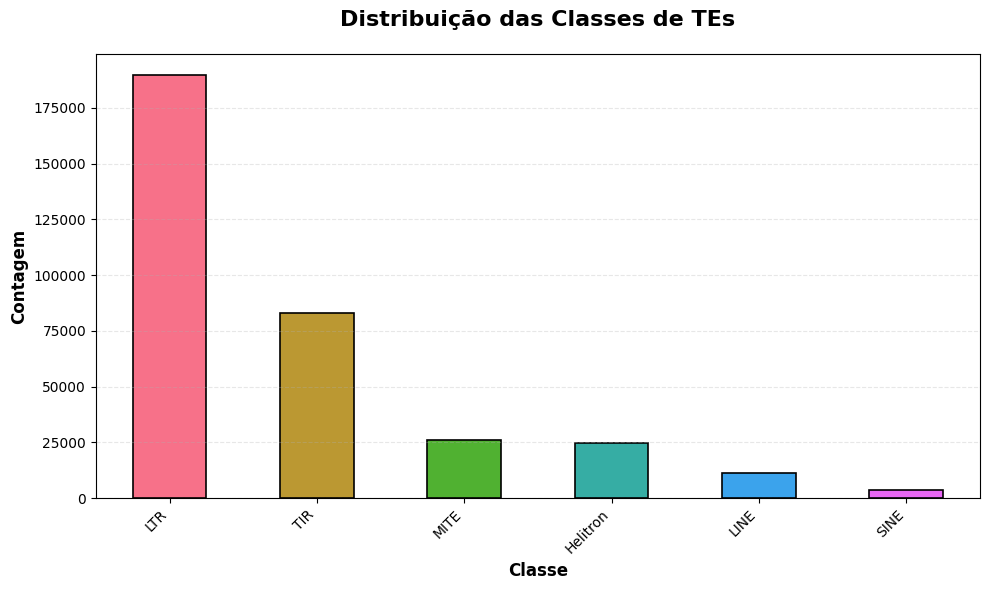

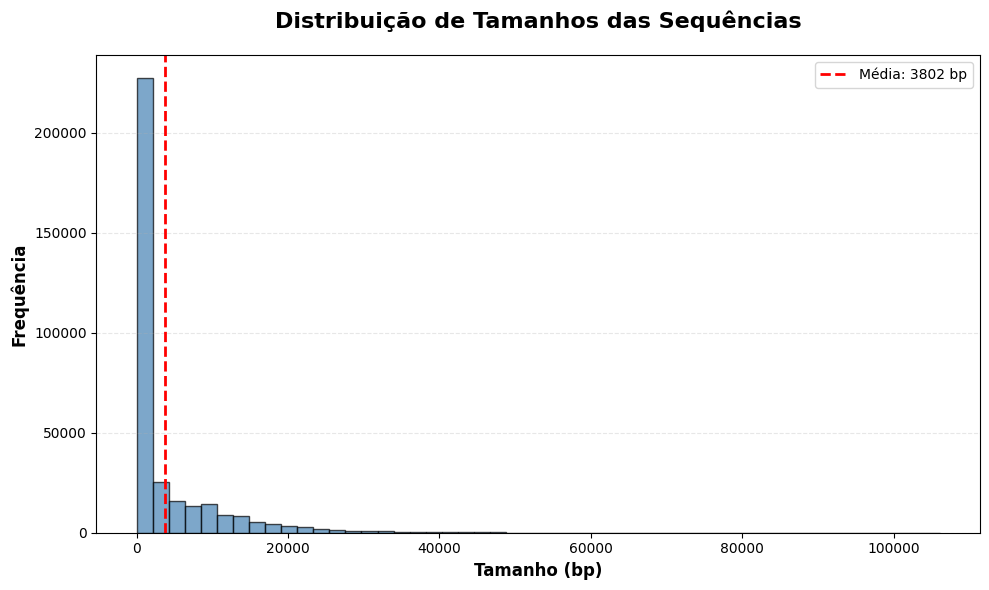

<Figure size 1200x600 with 0 Axes>

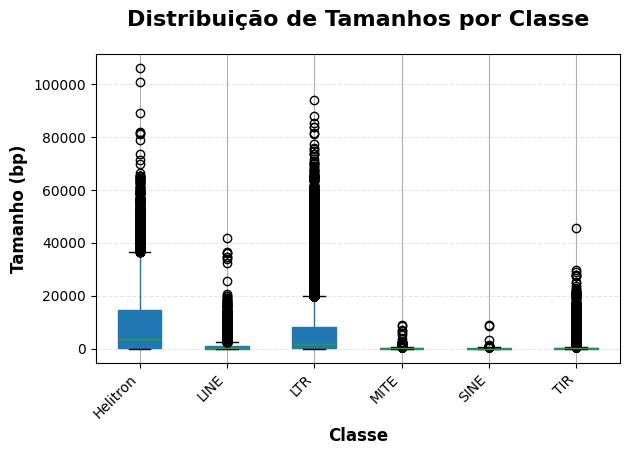

<Figure size 1200x600 with 0 Axes>

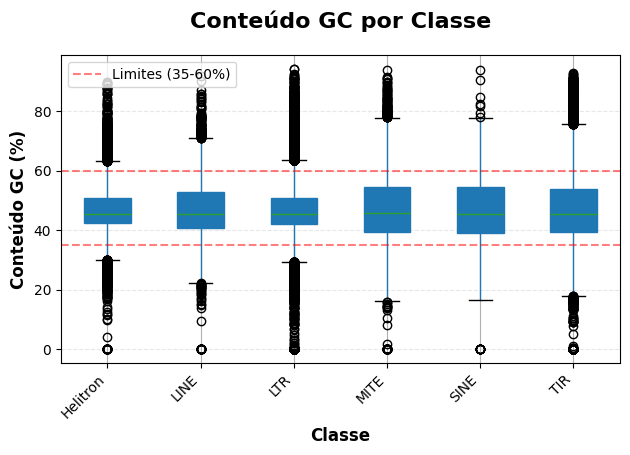


Removendo duplicatas
Removidas: 24219
Removendo caracteres inválidos
Removidas: 1
Removendo sequências <30bp
Removidas: 1328
Aplicando filtros de tamanho por classe
Removidas: 157738
Removendo sequências com >0.0% Ns
Removidas: 277
Filtrando GC% (35-60%)
Removidas: 19265
Total removido: 202828 (59.9%)


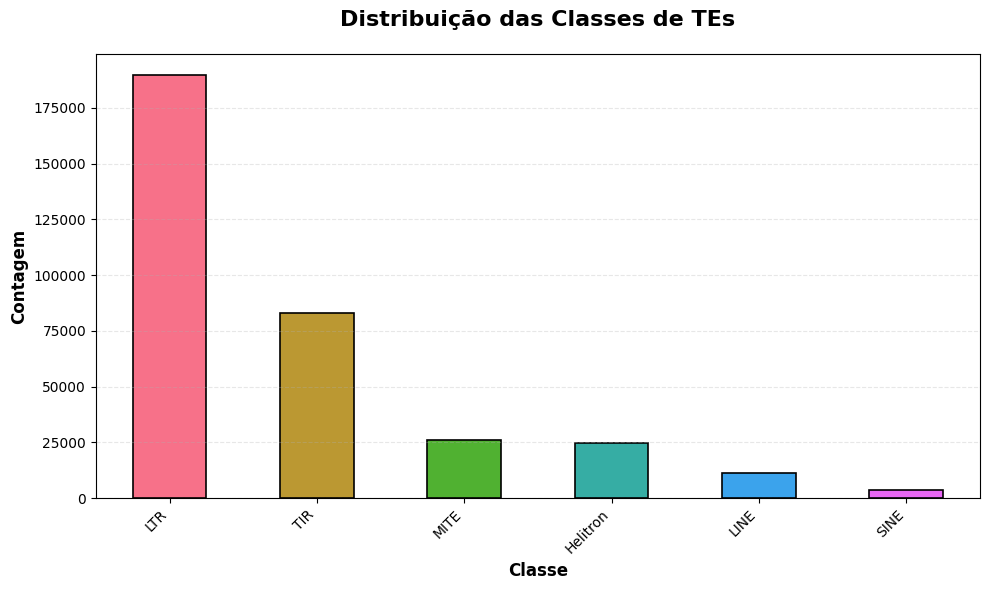

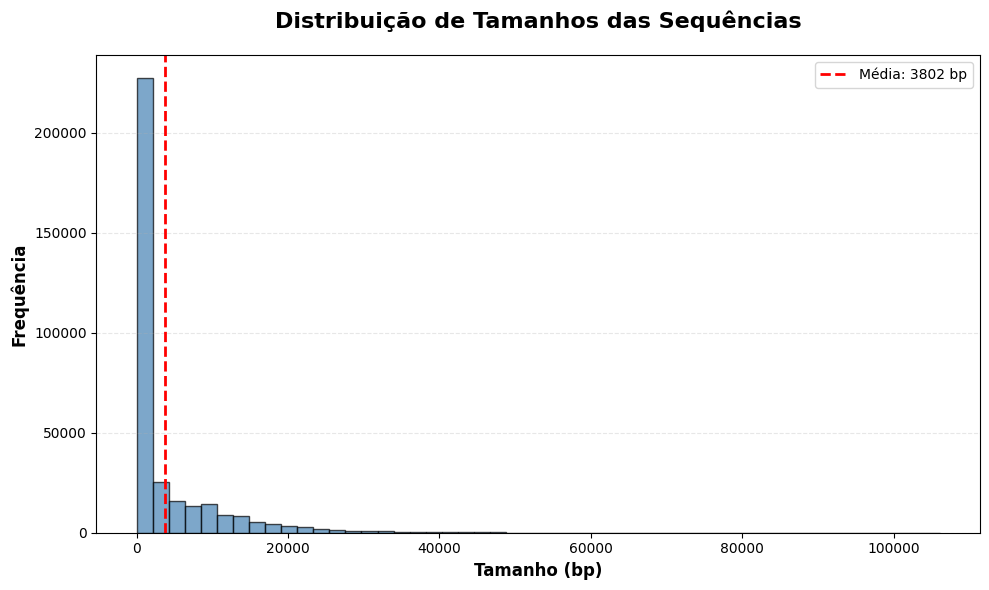

<Figure size 1200x600 with 0 Axes>

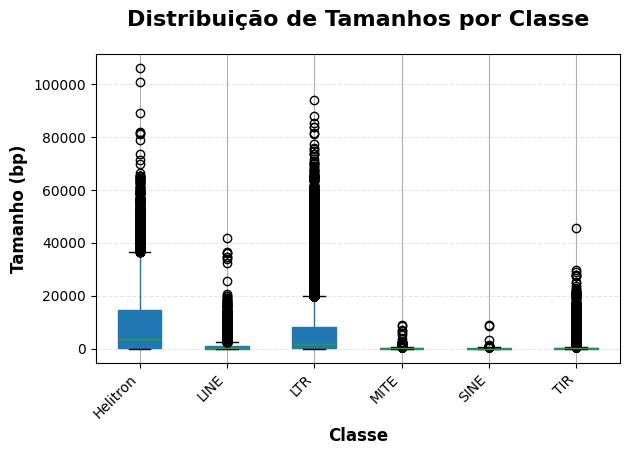

<Figure size 1200x600 with 0 Axes>

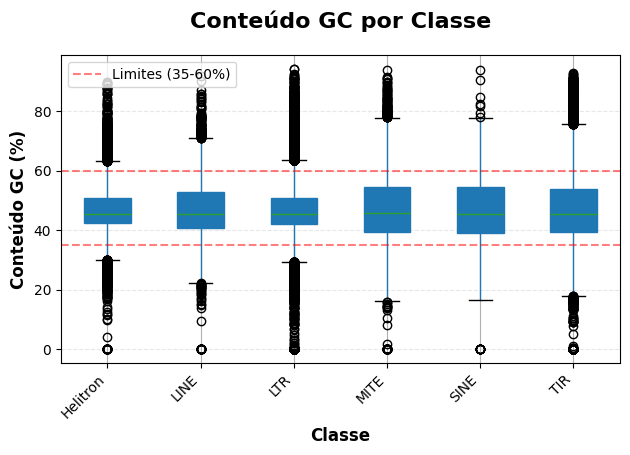

In [16]:
# Carregando CSV
csv_file = 'sequencias_TEs.csv'
cleaner = carregar_csv(csv_file)

mostrar_estatisticas(cleaner)
visualizar_dados(cleaner, "original")
# Limpando dataset
limpar_dados(cleaner)
visualizar_dados(cleaner, "limpo")

In [17]:
# Extração das features
"""
config_path = 'mathfeature_config.yaml'
with open(config_path, 'w') as f:
    yaml.dump(mathfeature_config, f, default_flow_style=False)

pipeline_features(config_path)
"""

# Pegando arquivo csv com as features já extraídas devido ao
# tempo de execução (excede o do colab)
!gdown --id 1sTqUFTYkEVSKMxb9jnsxyFMxu9xIylyO -O features_full.csv
df = pd.read_csv('features_full.csv')

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1sTqUFTYkEVSKMxb9jnsxyFMxu9xIylyO
From (redirected): https://drive.google.com/uc?id=1sTqUFTYkEVSKMxb9jnsxyFMxu9xIylyO&confirm=t&uuid=eadd465e-7f99-4bfb-a8bd-722017815108
To: /content/features_full.csv
100% 282M/282M [00:02<00:00, 95.9MB/s]


In [18]:
# Pré-processamento
df_final, features_selecionadas = limpar_features = limpar_features(df)

Removidas 0 features constantes
Removidas 10 features duplicadas
Removidas 3 features altamente correlacionadas

30 features selecionadas (supervisionadas)
Features: ['length', 'TNC_AAC', 'TNC_ACC', 'TNC_ACG', 'TNC_ACT', 'TNC_AGC', 'TNC_AGT', 'TNC_ATC', 'TNC_CAC', 'TNC_CCA', 'TNC_CGT', 'TNC_CTA', 'TNC_GAC', 'TNC_GAT', 'TNC_GCA', 'TNC_GCT', 'TNC_GGA', 'TNC_GGT', 'TNC_GTA', 'TNC_GTC', 'TNC_GTG', 'TNC_TAC', 'TNC_TAG', 'TNC_TCC', 'TNC_TGC', 'ORF_maximum_ORF_length', 'ORF_std_ORF_length', 'ORF_average_ORF_length', 'ORF_cv_ORF_length', 'Shannon_k3_k3']


In [19]:
# Treinamento do modelo
clf, X_treino, X_teste, y_treino, y_teste, le, classes = random_forest(df_final)

Classes encontradas: ['Helitron' 'LINE' 'LTR' 'MITE' 'SINE' 'TIR']
Mapeamento: {'Helitron': 0, 'LINE': 1, 'LTR': 2, 'MITE': 3, 'SINE': 4, 'TIR': 5}


In [20]:
# Aplicação da função de avaliação de desempenho sobre os conjuntos de treino e de teste
acc_treino, pr_treino, roc_treino, classes, y_treino_bin, y_treino_score = evaluate(clf, X_treino, y_treino, "Treino")
acc_teste, pr_teste, roc_teste, _, y_teste_bin, y_teste_score = evaluate(clf, X_teste, y_teste, "Teste")


 Treino — Acurácia: 0.8247 | PR-AUC macro: 0.7809 | ROC-AUC macro: 0.9339

 Teste — Acurácia: 0.8183 | PR-AUC macro: 0.4951 | ROC-AUC macro: 0.8718


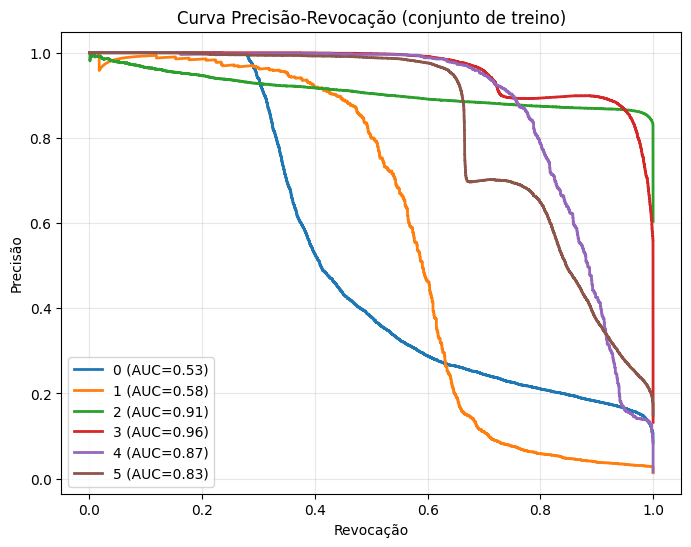

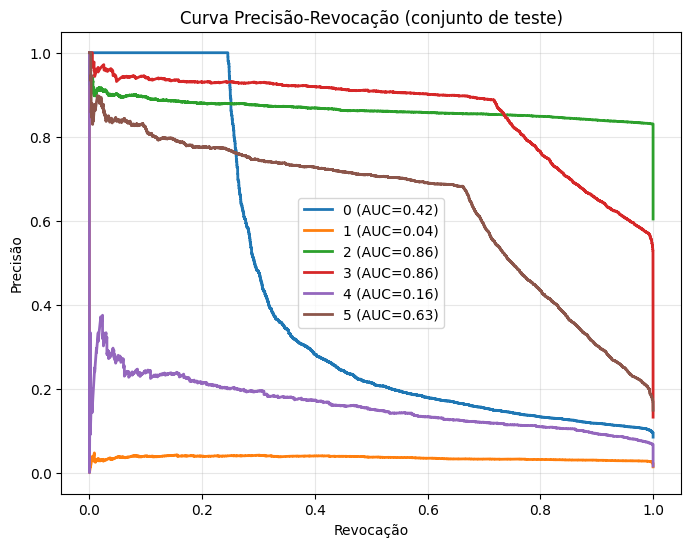

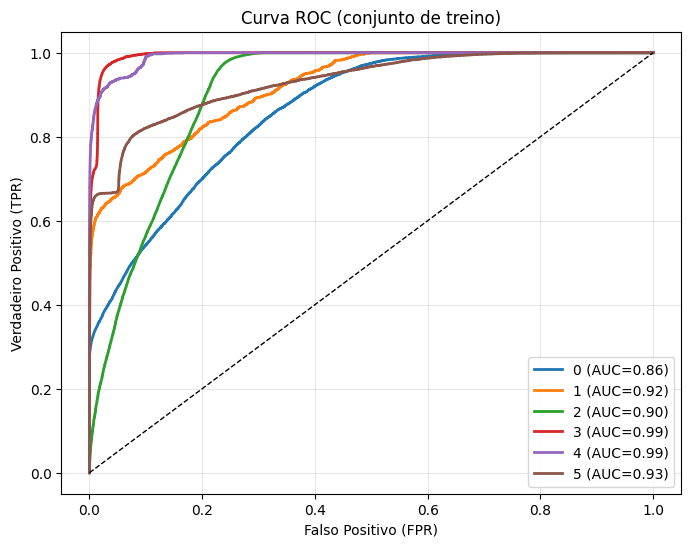

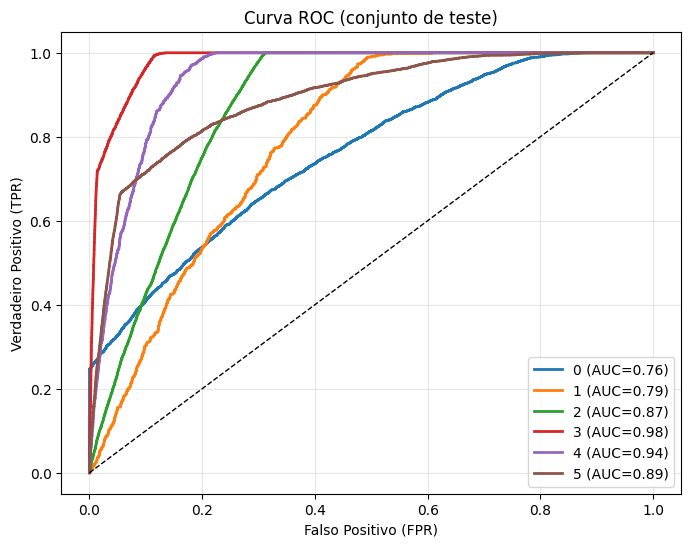

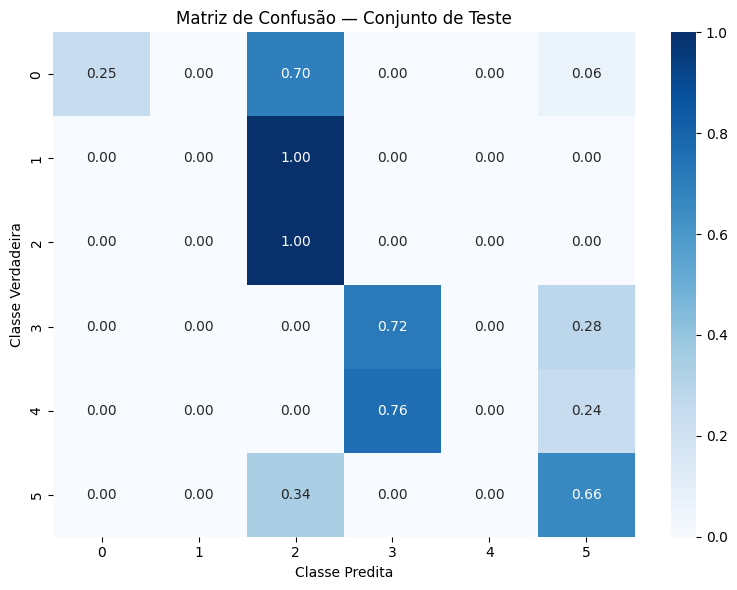

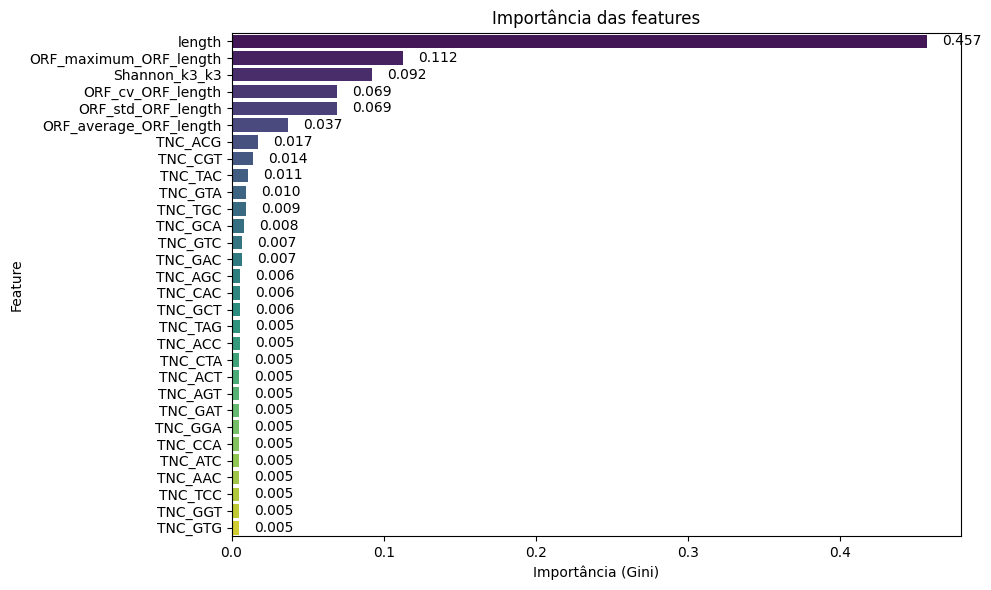

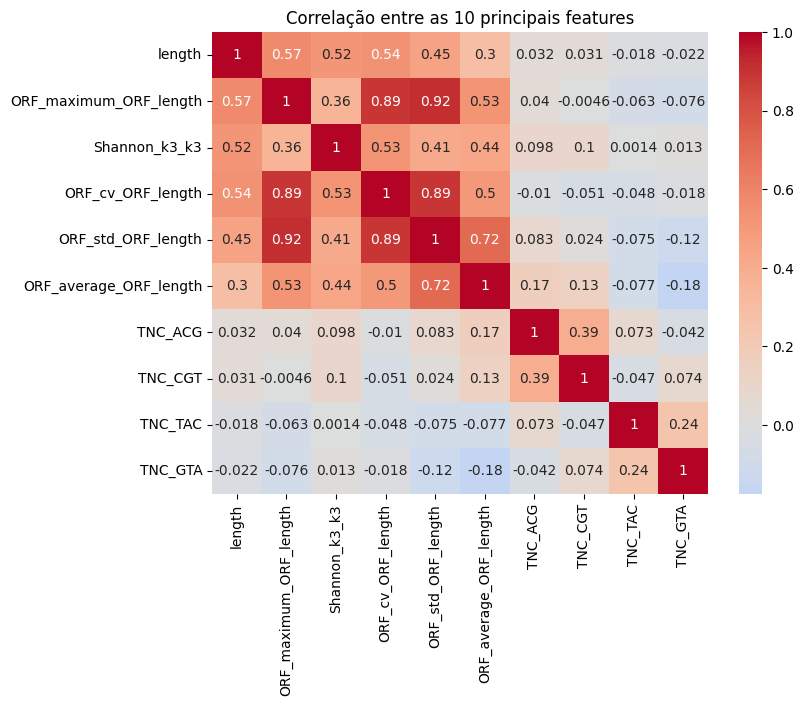

In [21]:
# Gráficos
pr_plot("treino", y_treino_bin, y_treino_score, classes)
pr_plot("teste", y_teste_bin, y_teste_score, classes)

roc_plot("treino", y_treino_bin, y_treino_score, classes)
roc_plot("teste", y_teste_bin, y_teste_score, classes)

# Matriz de Confusão
y_previsao_teste = clf.predict(X_teste)
cm = confusion_matrix(y_teste, y_previsao_teste, labels=classes, normalize="true")

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)

plt.title("Matriz de Confusão — Conjunto de Teste")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Verdadeira")
plt.tight_layout()
plt.show()

# Importância de cada feature
importancias = clf.feature_importances_
# USAR AS FEATURES QUE FORAM RETORNADAS PELA FUNÇÃO limpar_features
# Assumindo que você chamou: df_final, features_selecionadas = limpar_features(...)
nome_features = features_selecionadas  # MUDANÇA AQUI

df_feat_imp = pd.DataFrame({
    "Feature": nome_features,
    "Importância": importancias
}).sort_values(by="Importância", ascending=False)

# Exibição das features ordenadas por importância
plt.figure(figsize=(10,6))
ax = sns.barplot(x="Importância", y="Feature", hue="Feature", data=df_feat_imp, palette="viridis", dodge=False, legend=False)
plt.title("Importância das features")
plt.xlabel("Importância (Gini)")
plt.ylabel("Feature")

# Adiciona o valor de cada barra
for p in ax.patches:
    width = p.get_width()  # valor da barra
    y = p.get_y() + p.get_height()/2
    ax.text(width + 0.01, y, f"{width:.3f}", va='center')

plt.tight_layout()
plt.show()

# Correlação normalizada entre as Top 10 features
top_features = df_feat_imp["Feature"].head(10).values
corr = df_final[top_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlação entre as 10 principais features")
plt.show()